In [56]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = True
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(0)

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import math
import random

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import common

    reload(common)


from common import (
    Env,
    EnvOffline,
    UnionFind,
    calc_centroid,
    calc_dist,
    calc_rectangle_area,
    construct_dist_matrix,
    construct_dist_matrix_rectangle,
    construct_graph,
    construct_sorted_edges,
    exponential_schedule,
    kruskals_algorithm,
    linear_schedule,
    my_deepcopy,
    prim,
    prim_k,
    prim_vs,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

### 辺のランキング誤差を W 毎にプロットしてみる


In [57]:
def calc_edge_list(env, points):
    edge_dists = []
    edge_id = 0
    for i in range(env.N):
        for j in range(i + 1, env.N):
            dist = calc_dist(points[i], points[j])
            edge_dists.append((dist, edge_id))
            edge_id += 1
    return sorted(edge_dists, key=lambda x: x[0])


def rank_sqrt_error(rank1, rank2):
    N = len(rank1)
    rank2_dict = {}
    for i, r2 in enumerate(rank2):
        rank2_dict[r2] = i

    cost = 0
    for i, v in enumerate(rank1):
        cost += abs(v - rank2_dict[v]) ** 2

    return cost / N


def rank_error(rank1, rank2):
    N = len(rank1)
    rank2_dict = {}
    for i, r2 in enumerate(rank2):
        rank2_dict[r2] = i

    cost = 0
    for i, v in enumerate(rank1):
        cost += abs(v - rank2_dict[v])

    return cost / N

In [58]:
envs = []
errors = []
for file_num in range(FILE_NUM):
    print(f"file_num: {file_num}")
    input_file_path = f"../in/{file_num:04d}.txt"
    output_file_path = f"../out/{file_num:04d}.txt"
    env = EnvOffline(input_file_path, output_file_path)

    edgeid_to_poinid = {}
    pointid_to_edgeid = {}
    edge_id = 0
    for i in range(env.N):
        for j in range(i + 1, env.N):
            edgeid_to_poinid[edge_id] = (i, j)
            pointid_to_edgeid[(i, j)] = edge_id
            edge_id += 1

    correct_edge_dists = calc_edge_list(env, env.coordinates)
    estimate_edge_dists = calc_edge_list(env, env.cneter_points)

    correct_ranks = [v[1] for v in correct_edge_dists]
    estimate_ranks = [v[1] for v in estimate_edge_dists]

    erorr = rank_error(correct_ranks, estimate_ranks)

    errors.append(erorr)
    envs.append(env)

file_num: 0
file_num: 1
file_num: 2
file_num: 3
file_num: 4
file_num: 5
file_num: 6
file_num: 7
file_num: 8
file_num: 9
file_num: 10
file_num: 11
file_num: 12
file_num: 13
file_num: 14
file_num: 15
file_num: 16
file_num: 17
file_num: 18
file_num: 19
file_num: 20
file_num: 21
file_num: 22
file_num: 23
file_num: 24
file_num: 25
file_num: 26
file_num: 27
file_num: 28
file_num: 29
file_num: 30
file_num: 31
file_num: 32
file_num: 33
file_num: 34
file_num: 35
file_num: 36
file_num: 37
file_num: 38
file_num: 39
file_num: 40
file_num: 41
file_num: 42
file_num: 43
file_num: 44
file_num: 45
file_num: 46
file_num: 47
file_num: 48
file_num: 49
file_num: 50
file_num: 51
file_num: 52
file_num: 53
file_num: 54
file_num: 55
file_num: 56
file_num: 57
file_num: 58
file_num: 59
file_num: 60
file_num: 61
file_num: 62
file_num: 63
file_num: 64
file_num: 65
file_num: 66
file_num: 67
file_num: 68
file_num: 69
file_num: 70
file_num: 71
file_num: 72
file_num: 73
file_num: 74
file_num: 75
file_num: 76
file_num:

In [60]:
avg_error = sum(errors) / len(errors)
print(f"avg_error: {avg_error}")

avg_error: 106562.97781001247


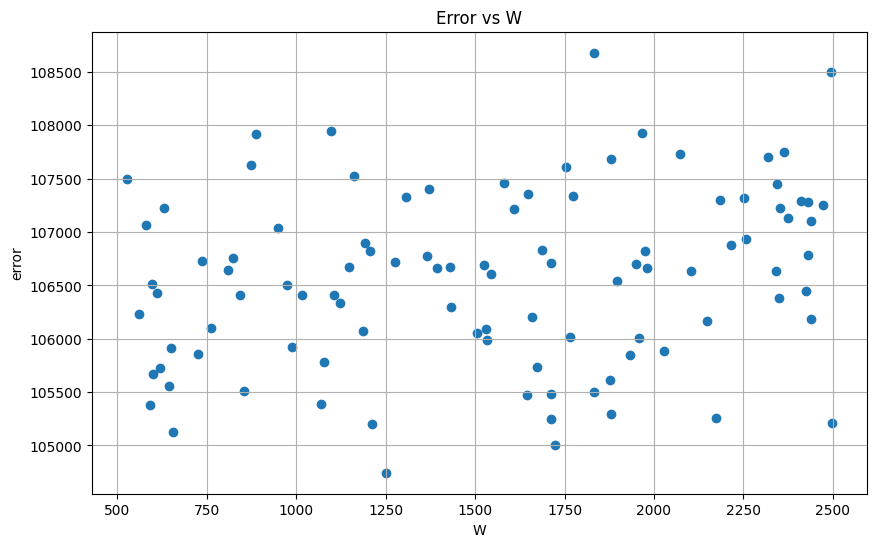

In [59]:
import matplotlib.pyplot as plt
import numpy as np

w_arr = [env.W for env in envs]


w_arr = np.array(w_arr)
errors_arr = np.array(errors)

plt.figure(figsize=(10, 6))
plt.scatter(w_arr, errors_arr)
plt.xlabel("W")
plt.ylabel("error")
plt.title("Error vs W")
plt.grid()
plt.show()